### **CELL 1: IMPORTS AND SETUP**

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import os

notebook_dir = os.getcwd()
if "analysis" in notebook_dir:
    base_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
else:
    base_dir = os.path.abspath(notebook_dir)

db_path = os.path.join(
    base_dir, "database", "sales.db").replace("\\", "/")
engine = create_engine(f"sqlite:///{db_path}")

def read_sql_file(filepath):
    if "analysis" in os.getcwd():
        full_path = os.path.abspath(
            os.path.join(os.getcwd(), "..", filepath))
    else:
        full_path = os.path.abspath(filepath)
    with open(full_path, "r") as f:
        return f.read()

def save_and_show(filename):
    os.makedirs(os.path.join(base_dir, "analysis", "charts"),
                exist_ok=True)
    plt.savefig(
        os.path.join(base_dir, "analysis", "charts", filename),
        dpi=150, bbox_inches="tight")
    plt.show()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

df = pd.read_sql("SELECT * FROM sales_clean", engine)

print("Setup complete")
print(f"Total rows in database: {len(df):,}")

Setup complete
Total rows in database: 1,234


### **CELL 2: KPI SUMMARY**

In [31]:
total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
total_lost = df["lost_revenue"].sum()
total_days = int(df["day_number"].max())
top_city = (df[df["city"] != "Unknown"].groupby("city")["revenue"].sum().idxmax())
top_product = (df.groupby("product_name")["revenue"].sum().idxmax())
most_lost = (df.groupby("product_name")["lost_revenue"].sum().idxmax())

print("E-COMMERCE PIPELINE - 30 DAY KPI SUMMARY")
print(f"Days of data            : {total_days}")
print(f"Total orders            : {total_orders:,}")
print(f"Total revenue earned    : Rs.{total_revenue:,.0f}")
print(f"Total revenue lost      : Rs.{total_lost:,.0f}")
print(f"Loss rate               : "f"{total_lost / (total_revenue + total_lost) * 100:.1f}%")
print(f"Top city                : {top_city}")
print(f"Top product (revenue)   : {top_product}")
print(f"Highest loss            : {most_lost}")


E-COMMERCE PIPELINE - 30 DAY KPI SUMMARY
Days of data            : 30
Total orders            : 1,207
Total revenue earned    : Rs.5,127,676
Total revenue lost      : Rs.1,586,704
Loss rate               : 23.6%
Top city                : Hyderabad
Top product (revenue)   : Power Bank
Highest loss            : Wireless Earbuds


### **CELL 3: ETL DATA QUALITY REPORT**

In [32]:
total_rows = len(df)

unknown_names = len(df[df["customer_name"] == "Unknown"])
unknown_phones = len(df[df["customer_phone"] == "Unknown"])
unknown_cities = len(df[df["city"] == "Unknown"])

invalid_phones = len(df[df["phone_valid"] == 0])

print("ETL PIPELINE - DATA QUALITY REPORT")
print(f"\nTotal rows processed: {total_rows:,}")
print()
print(f"Missing customer names: {unknown_names}"f" ({unknown_names / total_rows * 100:.1f}%)")
print(f"Missing phone numbers : {unknown_phones}"f" ({unknown_phones / total_rows * 100:.1f}%)")
print(f"Missing city values   : {unknown_cities}"f" ({unknown_cities / total_rows * 100:.1f}%)")
print(f"Invalid phone numbers : {invalid_phones}"f" ({invalid_phones / total_rows * 100:.1f}%)")

print()
print("How each issue was handled:\n")
print("Missing values   : filled with 'Unknown'")
print("Wrong casing     : fixed with .str.title()")
print("Phone formatting : cleaned with .str.replace()")
print("Duplicate orders : removed with drop_duplicates()")
print("Invalid phones   : flagged in phone_valid column")

ETL PIPELINE - DATA QUALITY REPORT

Total rows processed: 1,234

Missing customer names: 111 (9.0%)
Missing phone numbers : 92 (7.5%)
Missing city values   : 104 (8.4%)
Invalid phone numbers : 181 (14.7%)

How each issue was handled:

Missing values   : filled with 'Unknown'
Wrong casing     : fixed with .str.title()
Phone formatting : cleaned with .str.replace()
Duplicate orders : removed with drop_duplicates()
Invalid phones   : flagged in phone_valid column


### **CELL 4: PAYMENT METHOD BREAKDOWN**

Payment Method Breakdown:
payment_method  total_orders  total_revenue  order_share_pct
           UPI           508        2049308            41.17
          Card           344        1562888            27.88
           COD           192         814779            15.56
   Net Banking           140         484241            11.35
        Wallet            50         216460             4.05



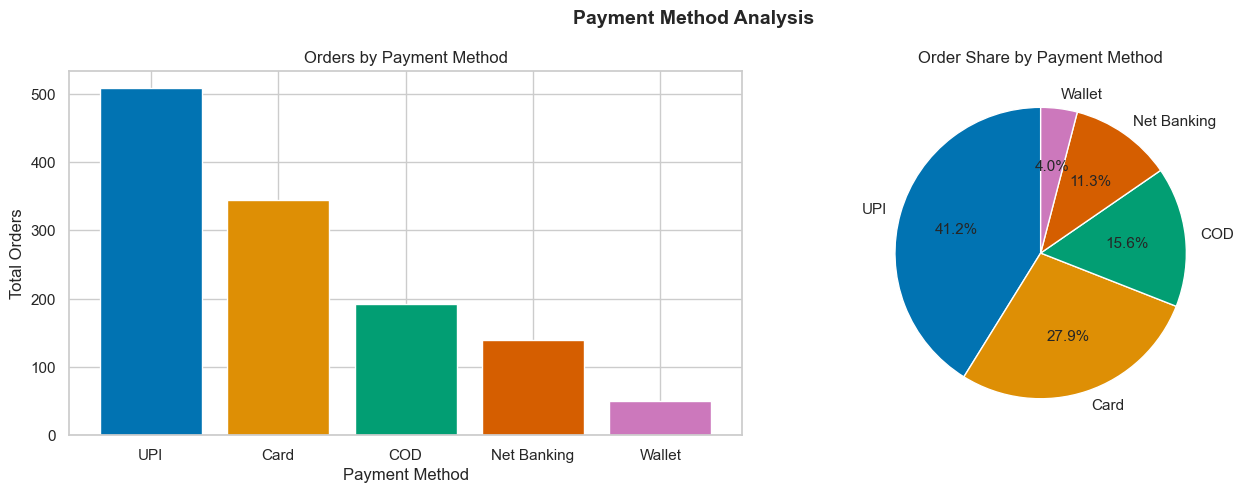

In [33]:
payment = pd.read_sql("""
                      SELECT 
                      payment_method,
                      COUNT(order_id) AS total_orders,
                      SUM(revenue) AS total_revenue,
                      ROUND(COUNT(order_id) * 100.0/
                      SUM(COUNT(order_id)) OVER (), 2) AS order_share_pct
                      FROM sales_clean
                      GROUP BY payment_method
                      ORDER BY total_orders DESC
                      """, engine)

print("Payment Method Breakdown:")
print(payment.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

my_colors = sns.color_palette("colorblind", 5)

#Left - bar chart
axes[0].bar(
    payment["payment_method"],
    payment["total_orders"],
    color = my_colors
)
axes[0].set_title("Orders by Payment Method")
axes[0].set_xlabel("Payment Method")
axes[0].set_ylabel("Total Orders")

#Right - pie chart
axes[1].pie(
    payment["order_share_pct"],
    labels = payment["payment_method"],
    autopct = "%1.1f%%",
    colors = my_colors,
    startangle = 90
)
axes[1].set_title("Order Share by Payment Method")

plt.suptitle("Payment Method Analysis", fontsize = 14, fontweight = "bold")
plt.tight_layout()
save_and_show("payment_methods.png")

**Insight:** Unsurprisingly, UPI dominates at 41% of all transactions, which makes perfect sense for the Indian market right now. It's closely followed by Card transactions which takes up 28%. While Cash on Delivery is still an option people use, the data shows our audience has overwhelmingly shifted to digital-first payments.

### **CELL 5: REVENUE CAPTURE RATE**

Revenue Capture Rate by Product:

        product_name  earned   lost  potential  capture_rate_pct
    Wireless Earbuds  582735 853212    1435947              40.6
     Creatine Powder  165416 147436     312852              52.9
          Face Serum  117214  78522     195736              59.9
            Gym Ball  193380 116907     310287              62.3
           Skin Tint  261382 137885     399267              65.5
    Sunscreen SPF 50  125216  51428     176644              70.9
   Fish Oil Capsules  155277  51120     206397              75.2
          Gym Gloves  123012  36720     159732              77.0
    Whey Protein Bar   72059  21229      93288              77.2
       Green Tea box  109242  29376     138618              78.8
           Jump Rope   93183  15007     108190              86.1
Multivitamin Tablets  218372  18434     236806              92.2
         Jade Roller  356700  21402     378102              94.3
     Sheet Mask Pack  172542   7527     180069          

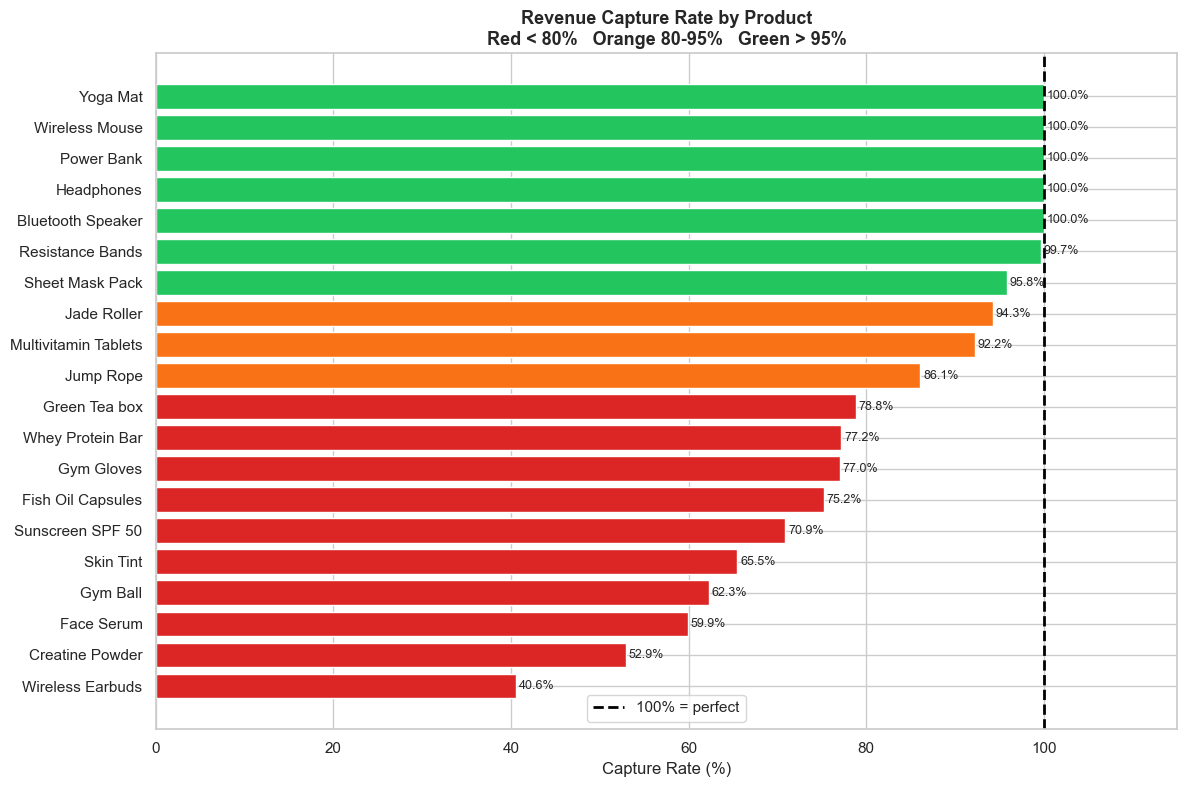

In [34]:
#QUESTION: How much of our potential revenue are we capturing?

# Potential = earned + lost
# Capture rate = earned / potential x 100

capture = pd.read_sql("""
                      SELECT
                      product_name,
                      SUM(revenue) AS earned,
                      SUM(lost_revenue) AS lost,
                      SUM(revenue) + SUM(lost_revenue) AS potential,
                      ROUND(SUM(revenue) * 100.0 / NULLIF(SUM(revenue) + SUM(lost_revenue), 0), 1) AS capture_rate_pct
                      FROM sales_clean
                      GROUP BY product_name
                      ORDER BY capture_rate_pct ASC
                      """, engine)

print("Revenue Capture Rate by Product:\n")
print(capture.to_string(index = False))
print()
print(f"Worst: {capture.iloc[0]['product_name']} "
      f"at {capture.iloc[0]['capture_rate_pct']}% capture rate")
print(f"Best : {capture.iloc[-1]['product_name']} "
      f"at {capture.iloc[-1]['capture_rate_pct']}% capture rate")


colors = ["#DC2626" if x < 80 else
          "#F97316" if x < 95 else
          "#22C55E"
          for x in capture["capture_rate_pct"]]

fig, ax = plt.subplots(figsize = (12, 8))
bars = ax.barh(
    capture["product_name"],
    capture["capture_rate_pct"],
    color = colors, edgecolor = "white")

ax.axvline(x = 100, color = "black", linestyle = "--",
           linewidth = 2, label = "100% = perfect")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f"{w:.1f}%", va = "center", fontsize = 9)

ax.set_title(
    "Revenue Capture Rate by Product\n"
    "Red < 80%   Orange 80-95%   Green > 95%",
    fontsize = 13, fontweight = "bold")
ax.set_xlabel("Capture Rate (%)")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
save_and_show("q1_capture_rate.png")

**Insight:** The capture rate exposes the exact gap between actual sales and true market demand. Wireless Earbuds suffered a catastrophic stockout, capturing only 40.6% of its potential revenue (earning Rs. 5.82 Lakhs but losing Rs. 8.53 Lakhs). Had the warehouse been adequately prepared for the viral spike, this single product could have generated over Rs. 14.3 Lakhs in revenue. Conversely, items at 100% (like the Yoga Mat) successfully captured all potential revenue with zero stockouts. This metric proves that evaluating a business solely on "revenue earned" completely hides the massive potential revenue being left on the table.

### **CELL 6: STOCKOUT SPREAD TIMELINE**

Stockout Timeline:

        product_name  stockout_day stockout_date  total_lost
    Wireless Earbuds             9    2024-03-09      853212
     Creatine Powder            16    2024-03-16      147436
          Face Serum            18    2024-03-18       78522
            Gym Ball            19    2024-03-19      116907
    Sunscreen SPF 50            20    2024-03-20       51428
           Skin Tint            21    2024-03-21      137885
    Whey Protein Bar            21    2024-03-21       21229
       Green Tea box            23    2024-03-23       29376
          Gym Gloves            23    2024-03-23       36720
   Fish Oil Capsules            24    2024-03-24       51120
           Jump Rope            26    2024-03-26       15007
         Jade Roller            28    2024-03-28       21402
     Sheet Mask Pack            28    2024-03-28        7527
Multivitamin Tablets            29    2024-03-29       18434
    Resistance Bands            30    2024-03-30         499

Fir

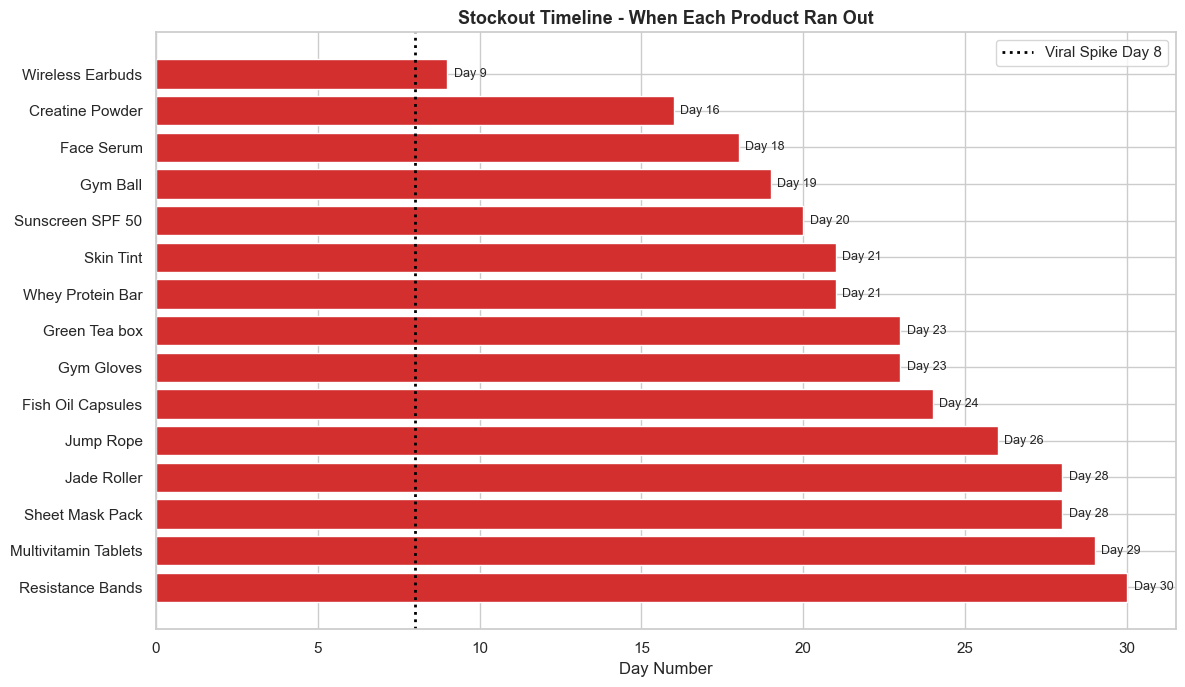

In [37]:
# QUESTION: How quickly did stockouts spread after Day 8?

stockout_timeline = pd.read_sql("""
                                SELECT
                                product_name,
                                MIN(CASE WHEN stock_remaining = 0
                                THEN day_number END) AS stockout_day,
                                MIN(CASE WHEN stock_remaining = 0
                                THEN date END) as stockout_date,
                                SUM(lost_revenue) AS total_lost
                                FROM sales_clean
                                GROUP BY product_name
                                HAVING stockout_day IS NOT NULL
                                ORDER BY stockout_day ASC
                                """, engine)

print("Stockout Timeline:\n")
print(stockout_timeline.to_string(index=False))
print()

first = int(stockout_timeline["stockout_day"].min())
last  = int(stockout_timeline["stockout_day"].max())
print(f"First stockout : Day {first}")
print(f"Last stockout  : Day {last}")
print(f"Spread over    : {last - first} days")
print(f"Products lost  : {len(stockout_timeline)}")

fig, ax = plt.subplots(figsize = (12, 7))

ax.barh(
    stockout_timeline["product_name"][::-1],
    stockout_timeline["stockout_day"][::-1],
    color = "#D32F2F", edgecolor = "white")

ax.axvline(x = 8, color = "black", linestyle = ":",
           linewidth = 2, label = "Viral Spike Day 8")

for i, (_, row) in enumerate(
        stockout_timeline[::-1].iterrows()):
    ax.text(row["stockout_day"] + 0.2, i,
            f"Day {int(row['stockout_day'])}",
            va = "center", fontsize = 9)

ax.set_title(
    "Stockout Timeline - When Each Product Ran Out",
    fontsize = 13, fontweight = "bold")
ax.set_xlabel("Day Number")
ax.legend()
plt.tight_layout()
save_and_show("q2_stockout_timeline.png")

**Insight:** The Day 8 viral spike triggered a cascade. Wireless Earbuds stocked out on Day 9, just 1 day after the spike. But the damage spread over the following 21 days as other products gradually ran dry. This spread shows the business had multiple windows to intervene. The automated pipeline's WARNING alerts on Day 15 for Creatine Powder (2 units remaining) gave exactly that window, but without a system to act on the alert, losses continued accumulating.

### **CELL 7: CITY IMPACT ANALYSIS**

City Impact Analysis:

     city  earned   lost  lost_rate_pct
Hyderabad 1675201 436828           20.0
Bengaluru 1361559 397783           22.0
   Mumbai  609703 202229           24.0
  Kolkata  392569 179713           31.0
   Punjab  336404  57526           14.0
  Chennai  373335  54620           12.0


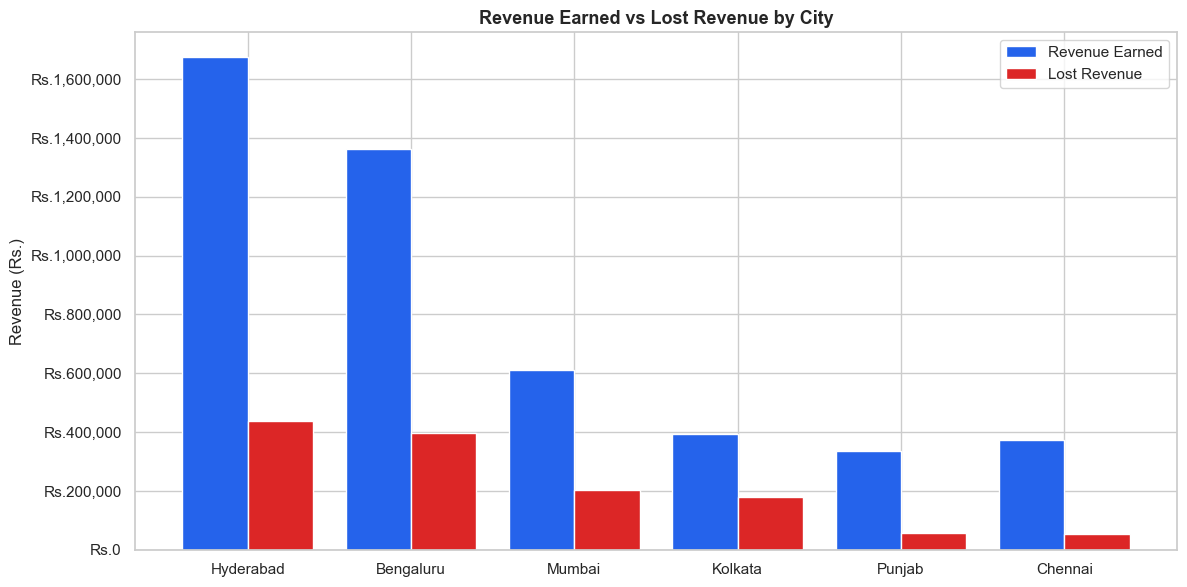

In [38]:
# QUESTION: Which cities are most underserved by stockouts?

city_impact  = pd.read_sql("""
                           SELECT
                           city,
                           SUM(revenue) as earned,
                           SUM(lost_revenue) AS lost,
                           ROUND(SUM(lost_revenue) * 100 / NULLIF(SUM(revenue) + SUM(lost_revenue), 0), 1) AS lost_rate_pct
                           FROM sales_clean
                           WHERE city != "Unknown"
                           GROUP BY city
                           ORDER BY lost DESC
                           """, engine)

print("City Impact Analysis:\n")
print(city_impact.to_string(index = False))

x = range(len(city_impact))
width = 0.4

fig, ax = plt.subplots(figsize = (12, 6))
ax.bar([i - width/2 for i in x],
       city_impact["earned"],
       width = width, label = "Revenue Earned",
       color = "#2563EB")
ax.bar([i + width/2 for i in x],
       city_impact["lost"],
       width = width, label = "Lost Revenue",
       color = "#DC2626")

ax.set_xticks(list(x))
ax.set_xticklabels(city_impact["city"])
ax.set_title("Revenue Earned vs Lost Revenue by City",
             fontsize = 13, fontweight = "bold")
ax.set_ylabel("Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
ax.legend()
plt.tight_layout()
save_and_show("q3_city_impact.png")

**Insight:** While the Power Bank was our top revenue driver, Wireless Earbuds actually generated the highest overall demand. Unfortunately, we couldn't fulfill nearly half of those orders due to severe stockouts, making it our largest missed opportunity.

### **CELL 9: CITY DEMAND**

Revenue and Orders by City:
NOTE: 99 orders with unknown cities were excluded from this city-level analysis.

     city  total_orders  total_revenue
Hyderabad           393        1962744
Bengaluru           279        1305557
   Mumbai           173         618272
  Kolkata           125         504283
  Chennai            90         382452
   Punjab            43         157914



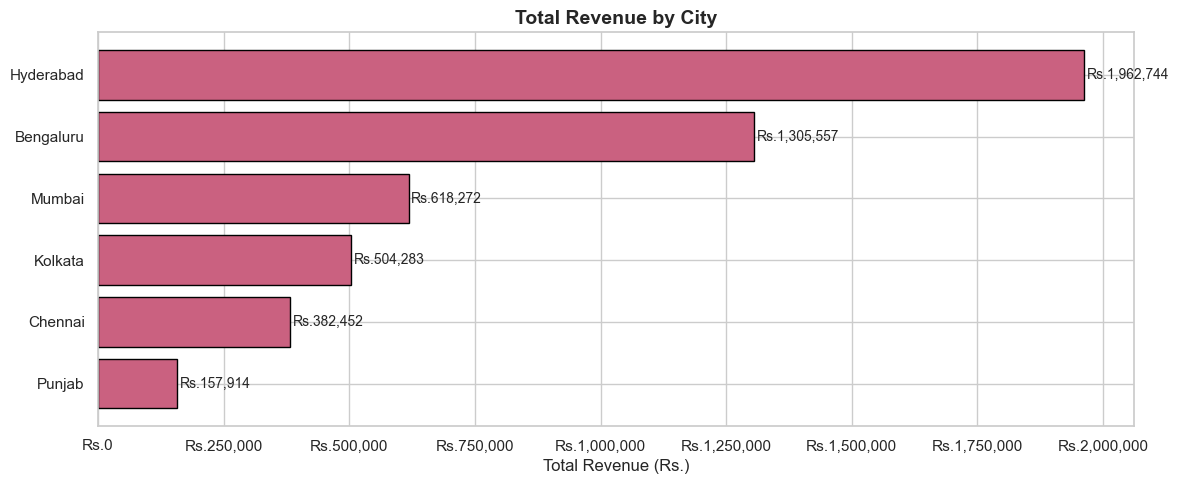

In [9]:
cities_df = pd.read_sql(
    read_sql_file("queries/city_demand.sql"), engine)

print("Revenue and Orders by City:")
print("NOTE: 99 orders with unknown cities were excluded from this city-level analysis.\n")
print(cities_df.to_string(index=False))
print()

fig, ax = plt.subplots()

bars = ax.barh(
    cities_df["city"][::-1],
    cities_df["total_revenue"][::-1],
    color = "#CA6180",
    edgecolor = "black"
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5000,
        bar.get_y() + bar.get_height() / 2,
        f"Rs.{width:,.0f}",
        va="center", fontsize=10
    )

ax.set_title("Total Revenue by City", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (Rs.)")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
plt.tight_layout()
save_and_show("chart4_city_demand.png")

**Insight:** Hyderabad and Bengaluru alone generate 60.4% of total revenue. These two cities should be the first priority for restocking and marketing campaigns. On the other hand, Punjab has the lowest demand so reduced inventory allocation is recommended there.

### **CELL 10: LOST REVENUE**

Lost Revenue by Product:
product_id      product_name  total_lost_units  total_lost_revenue first_stockout_date
       P01  Wireless Earbuds               270              593730          2024-03-10
       P16   Creatine Powder               149              133951          2024-03-15
       P10          Gym Ball               115              101085          2024-03-20
       P12        Face Serum               120               68280          2024-03-21
       P17 Fish Oil Capsules                74               47286          2024-03-25
       P11  Sunscreen SPF 50                82               45838          2024-03-24
       P20  Whey Protein Bar               119               35581          2024-03-20
       P19     Green Tea box                52               23868          2024-03-24
       P08        Gym Gloves                51               23409          2024-03-26
       P14         Skin Tint                18               21582          2024-03-26
       P06        

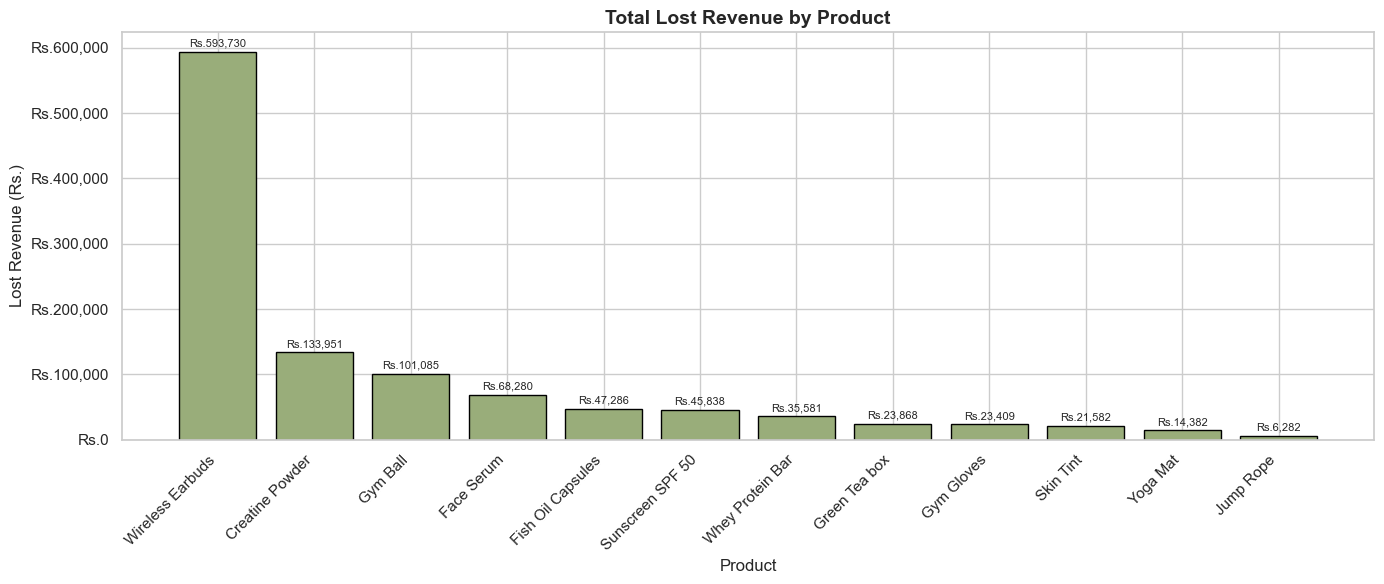

In [10]:
lost_df = pd.read_sql(
    read_sql_file("queries/lost_revenue.sql"), engine)

print("Lost Revenue by Product:")
print(lost_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(14,6))

bars = ax.bar(
    lost_df["product_name"],
    lost_df["total_lost_revenue"],
    color = "#99AD7A",
    edgecolor="black",
    linewidth=1
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5000,
        f"Rs.{height:,.0f}",
        ha="center", va="bottom", fontsize=8
    )

ax.set_title("Total Lost Revenue by Product", fontsize=14, fontweight="bold")
ax.set_xlabel("Product")
ax.set_ylabel("Lost Revenue (Rs.)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rs.{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_and_show("chart5_lost_revenue.png")

**Insight:** 12 producs experienced stockouts over 30 days. Wireless Earbuds accounts for the majority of lost revenue at Rs. 5,93,730. 

### **CELL 11: REORDER ALERT SYSTEM**

In [11]:
reorder_df = pd.read_sql(
    read_sql_file("queries/reorder_alert.sql"), engine)

reorder_now = reorder_df[reorder_df["alert_status"] == "REORDER NOW"]

ok = reorder_df[reorder_df["alert_status"] == "OK"]

print("="*40)
print("PRODUCTS NEEDING IMMEDIATE REORDER")
print("="*40)
print(reorder_now.to_string(index=False))
print()

print("="*40)
print("PRODUCTS WITH HEALTHY STOCK LEVELS")
print("="*40)
print(ok.to_string(index=False))
print()

print(f"Products flagged REORDER NOW: {len(reorder_now)}")
print(f"Products with OK status: {len(ok)}")
print(f"Total lost revenue (all): "f"Rs.{reorder_df['lost_revenue_so_far'].sum():,.0f}")


PRODUCTS NEEDING IMMEDIATE REORDER
product_id      product_name  current_stock  reorder_threshold  lost_revenue_so_far alert_status
       P01  Wireless Earbuds              0               38.0               593730  REORDER NOW
       P16   Creatine Powder              0               23.0               133951  REORDER NOW
       P10          Gym Ball              0               22.0               101085  REORDER NOW
       P12        Face Serum              0               22.0                68280  REORDER NOW
       P17 Fish Oil Capsules              0               22.0                47286  REORDER NOW
       P11  Sunscreen SPF 50              0               21.0                45838  REORDER NOW
       P20  Whey Protein Bar              0               24.0                35581  REORDER NOW
       P19     Green Tea box              0               19.0                23868  REORDER NOW
       P08        Gym Gloves              0               21.0                23409  REORDER

**Insight:** 18 out of 20 products need immediate restocking. The reorder threshold is calculated dynamically as average daily sales x 2 - giving a 2-day buffer before stock runs out. Implementing this in production would prevent the losses seen here.